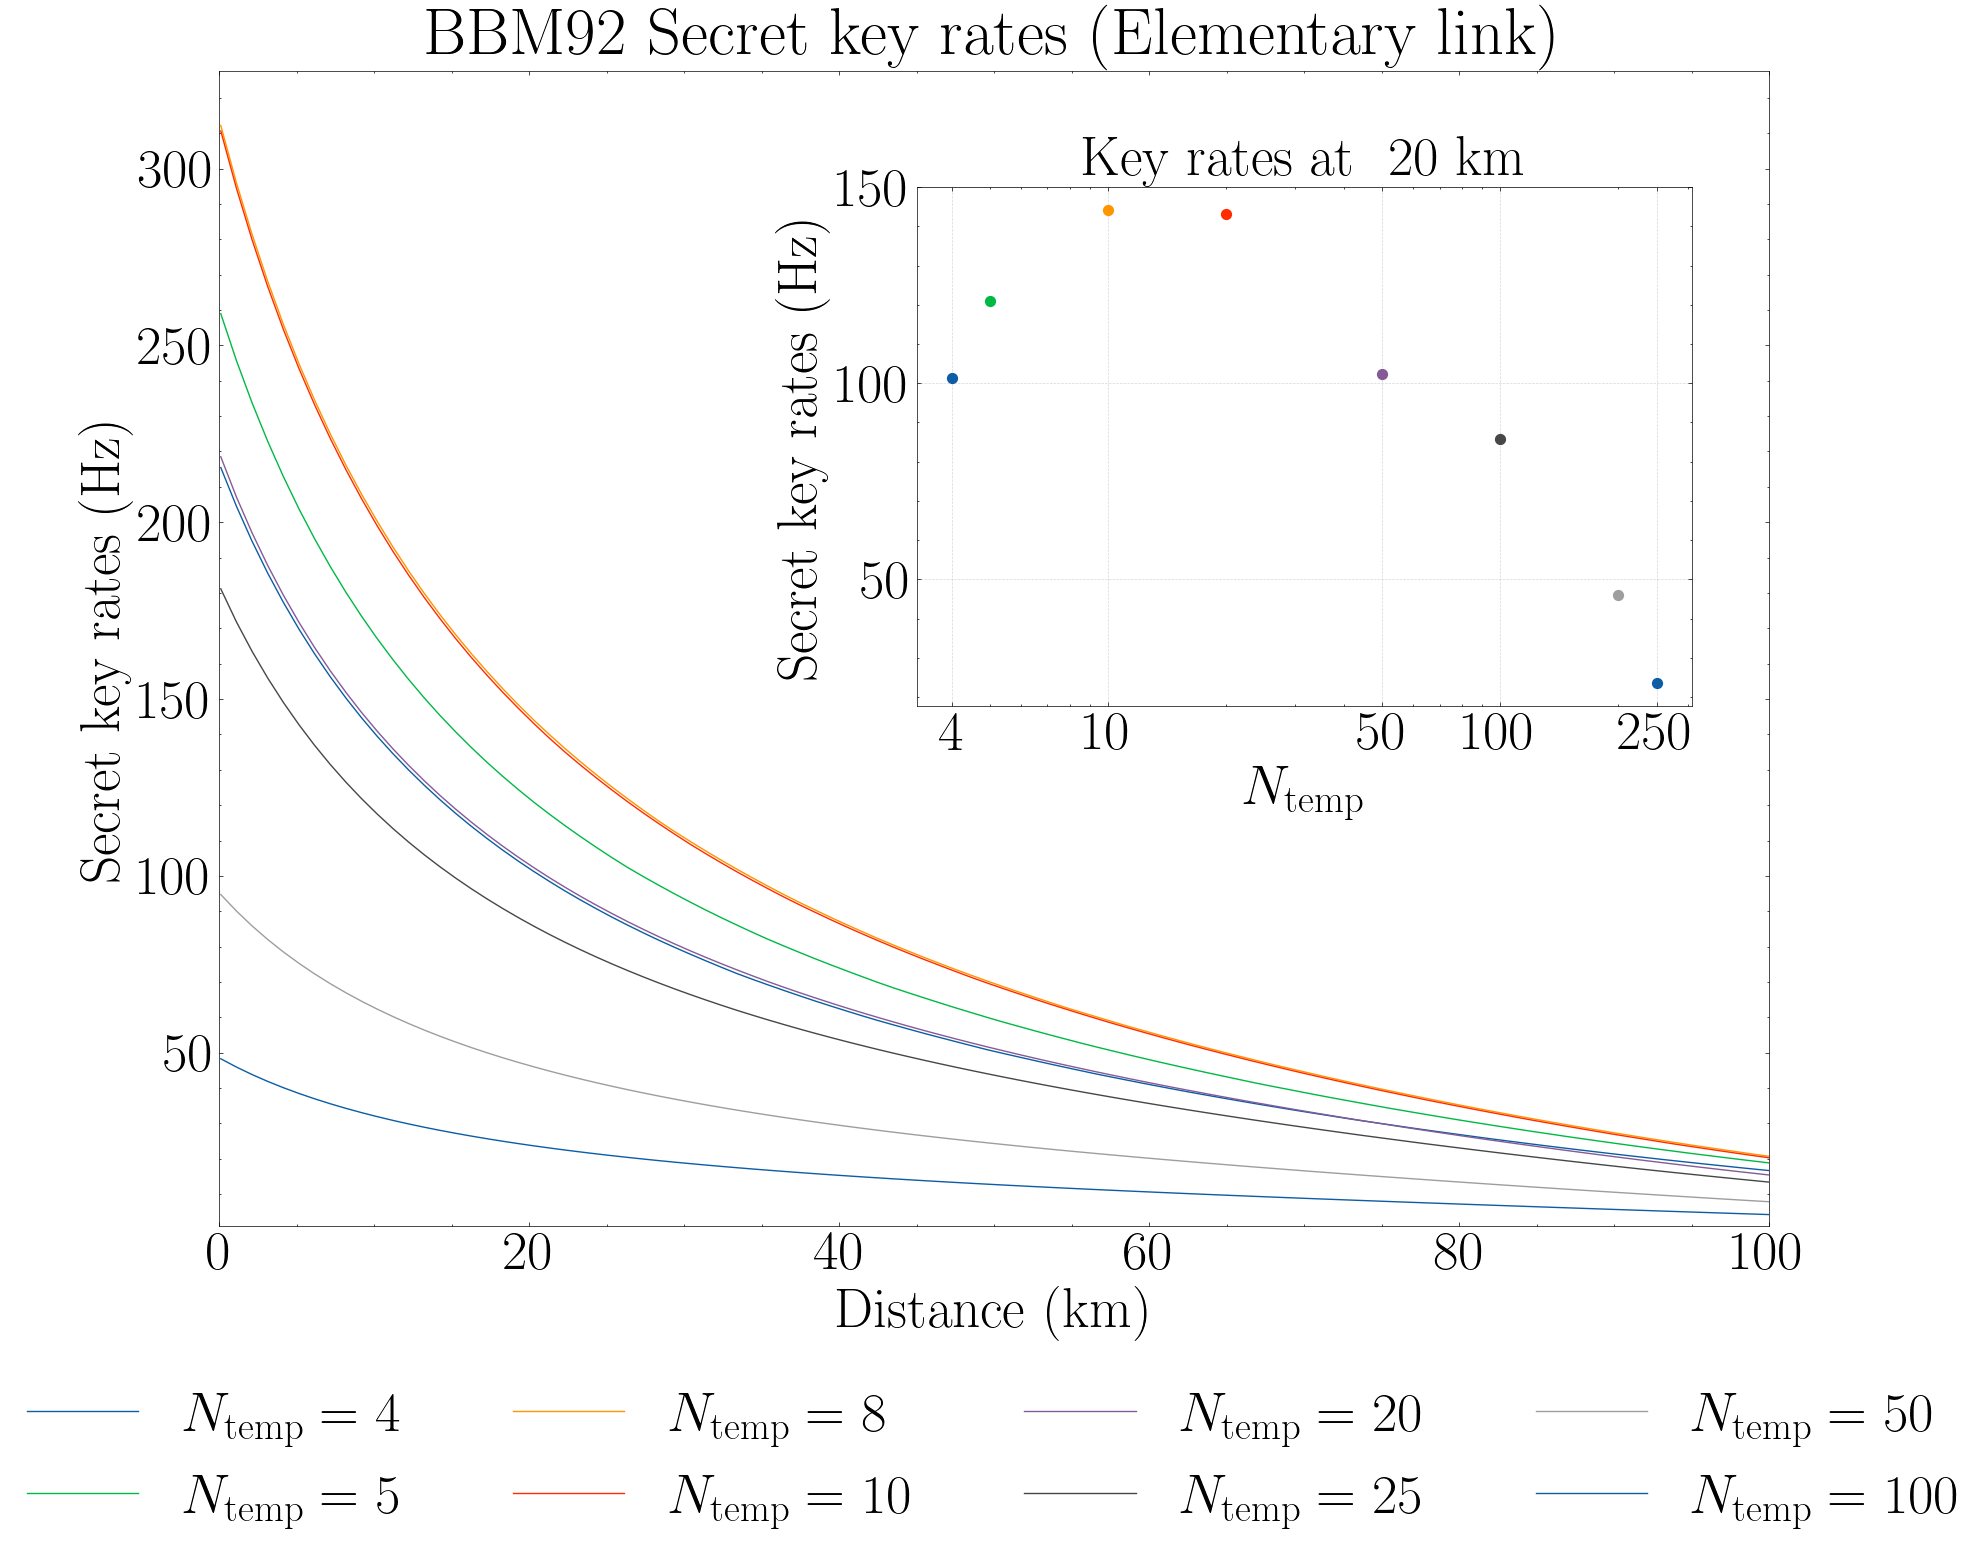

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
%matplotlib inline

plt.style.use(['science'])

pra_params = {
    # # 'figure.figsize': (4.725, 3.5), 
    # 'figure.figsize': (3.15, 2.33),
    'font.size': 40,
    'text.usetex': True,            
    'font.family': 'serif',         
    'font.serif': ['Computer Modern Roman'], 
    
}

plt.rcParams.update(pra_params)

# --- 1. Load Data ---
sk_rates_2hop_atom_n_temp_2 = np.load('sk_rates_2hop_hybrid_n_temp_2.npy', allow_pickle=True)
sk_rates_2hop_atom_n_temp_4 = np.load('sk_rates_2hop_hybrid_n_temp_4.npy', allow_pickle=True)
sk_rates_2hop_atom_n_temp_5 = np.load('sk_rates_2hop_hybrid_n_temp_5.npy', allow_pickle=True)
sk_rates_2hop_atom_n_temp_8 = np.load('sk_rates_2hop_hybrid_n_temp_8.npy', allow_pickle=True)
sk_rates_2hop_atom_n_temp_10 = np.load('sk_rates_2hop_hybrid_n_temp_10.npy', allow_pickle=True)
sk_rates_2hop_atom_n_temp_20 = np.load('sk_rates_2hop_hybrid_n_temp_20.npy', allow_pickle=True)
sk_rates_2hop_atom_n_temp_25 = np.load('sk_rates_2hop_hybrid_n_temp_25.npy', allow_pickle=True)
sk_rates_2hop_atom_n_temp_50 = np.load('sk_rates_2hop_hybrid_n_temp_50.npy', allow_pickle=True)
sk_rates_2hop_atom_n_temp_100 = np.load('sk_rates_2hop_hybrid_n_temp_100.npy', allow_pickle=True)
sk_rates_2hop_atom_n_temp_125 = np.load('sk_rates_2hop_hybrid_n_temp_125.npy', allow_pickle=True)
sk_rates_2hop_atom_n_temp_200 = np.load('sk_rates_2hop_hybrid_n_temp_200.npy', allow_pickle=True)
sk_rates_2hop_atom_n_temp_250 = np.load('sk_rates_2hop_hybrid_n_temp_250.npy', allow_pickle=True)
sk_rates_2hop_atom_n_temp_500 = np.load('sk_rates_2hop_hybrid_n_temp_500.npy', allow_pickle=True)
sk_rates_2hop_atom_n_temp_1000 = np.load('sk_rates_2hop_hybrid_n_temp_1000.npy', allow_pickle=True)

distances = np.linspace(0.1, 100, 100)

# --- 2. Main Plot Setup ---
fig, ax = plt.subplots(figsize=(20, 15))

ax.set_title(r"BBM92 Secret key rates (Elementary link)")
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Secret key rates (Hz)')

# Plot and assign to variables to extract their colors later for the inset
# l1, = ax.plot(distances, sk_rates_2hop_atom_n_temp_2, label=r'$N_\text{temp} = 2$')
l1, = ax.plot(distances, sk_rates_2hop_atom_n_temp_4, label=r'$N_\text{temp} = 4$')
l2, = ax.plot(distances, sk_rates_2hop_atom_n_temp_5, label=r'$N_\text{temp} = 5$')
l3, = ax.plot(distances, sk_rates_2hop_atom_n_temp_8, label=r'$N_\text{temp} = 8$')
l4, = ax.plot(distances, sk_rates_2hop_atom_n_temp_10, label=r'$N_\text{temp} = 10$')
l5, = ax.plot(distances, sk_rates_2hop_atom_n_temp_20, label=r'$N_\text{temp} = 20$')
l6, = ax.plot(distances, sk_rates_2hop_atom_n_temp_25, label=r'$N_\text{temp} = 25$')
l7, = ax.plot(distances, sk_rates_2hop_atom_n_temp_50, label=r'$N_\text{temp} = 50$')
l8, = ax.plot(distances, sk_rates_2hop_atom_n_temp_100, label=r'$N_\text{temp} = 100$')
# l10, = ax.plot(distances, sk_rates_2hop_atom_n_temp_125, label=r'$N_\text{temp} = 125$')
# l11, = ax.plot(distances, sk_rates_2hop_atom_n_temp_200, label=r'$N_\text{temp} = 200$')
# l12, = ax.plot(distances, sk_rates_2hop_atom_n_temp_250, label=r'$N_\text{temp} = 250$')
# l13, = ax.plot(distances, sk_rates_2hop_atom_n_temp_500, label=r'$N_\text{temp} = 500$')
# l14, = ax.plot(distances, sk_rates_2hop_atom_n_temp_1000, label=r'$N_\text{temp} = 1000$')

ax.set_ylim(bottom=10**0)
ax.set_xlim(0, 100)
# ax.set_yscale('log')

# --- 3. Reposition Legend Below Axis ---
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4)

# --- 4. Create Inset Scatter Plot ---
# [x0, y0, width, height] relative to main axes. Adjust these to move/resize the inset.
ax_inset = ax.inset_axes([0.45, 0.45, 0.5, 0.45])

# Pick a distance index (index 20 corresponds to roughly 20 km)
idx = 20 
target_dist = distances[idx]

N_temps = [4, 5, 10, 20, 50, 100, 200, 250]
rates_at_dist = [
    sk_rates_2hop_atom_n_temp_4[idx],
    sk_rates_2hop_atom_n_temp_5[idx],
    sk_rates_2hop_atom_n_temp_8[idx],
    sk_rates_2hop_atom_n_temp_10[idx],
    sk_rates_2hop_atom_n_temp_20[idx],
    sk_rates_2hop_atom_n_temp_25[idx],
    sk_rates_2hop_atom_n_temp_50[idx],
    sk_rates_2hop_atom_n_temp_100[idx]
]
# Extract the exact colors used in the main plot
colors = [l.get_color() for l in [l1, l2, l3, l4, l5, l6, l7, l8]]

# Plot the scatter points
for N, rate, color in zip(N_temps, rates_at_dist, colors):
    ax_inset.scatter(N, rate, color=color, s=50, zorder=3)

# Style the inset
ax_inset.set_title(f'Key rates at ~{target_dist:.0f} km', fontsize=40)
ax_inset.set_xlabel(r'$N_\text{temp}$', fontsize=40)
ax_inset.set_ylabel('Secret key rates (Hz)', fontsize=40)
ax_inset.grid(True, linestyle='--', alpha=0.5)

# Use log scale to spread the N_temps out nicely
ax_inset.set_xscale('log')
from matplotlib.ticker import ScalarFormatter
ax_inset.xaxis.set_major_formatter(ScalarFormatter())
ax_inset.set_xticks([4, 10, 50, 100, 250]) 

# --- 5. Save and Show ---
# bbox_inches='tight' is crucial here so the bottom legend isn't cut off!
plt.savefig('multiplexing_tradeoff.pdf', bbox_inches='tight')
plt.show()